# Choice task 3
## Pretrain the backbone on cat-dog classification
This is done in a jupyter notebook, as it re-uses lots of code from the 3rd assignment, which is better suited for classification. Doing this seperately will prevent lots of that old code from ending up scattered throughout the new object detection code from the current assignment.

For readability, the code is divided into sections, building the process chronologically, rather than defining all classes and functions first, then using them.

**NOTE:** This notebook only does the pre-training. The resulting model can be used as starting point for further training using the `start_from_checkpoint_path` entry in the config file.

### 0. Configuration

In [1]:
import sys
sys.path.append("../")

# This assumes your data has already been downloaded, 
# see the assignment for where to get them.
DATA_ROOT_DIR = "data/cat-dog-classification/"
OUTPUT_MODEL_PATH = "models/classification_backbone.pth"

IMG_SIZE = 112
VAL_SIZE = .2
BATCH_SIZE = 32
NUM_WORKERS = 4
N_EPOCHS = 50
LEARNING_RATE = 0.00001

In [2]:
import copy
import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm import tqdm

from create_logger import create_basic_logger
from data import to_dataloaders
from yolov1_base import YOLOv1Base


torch.manual_seed(42)
DEVICE = torch.accelerator.current_accelerator().type if \
    torch.accelerator.is_available() else "cpu"
print(f"Using device: {DEVICE}")

logger = create_basic_logger(name="choice task 3")

Using device: cuda


### 1. Loading the data

In [3]:
dataset = ImageFolder(
    root=DATA_ROOT_DIR, 
    transform=transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        # These numbers are from ImageNet, for normalisation.
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],   
            std=[0.229, 0.224, 0.225]
        )
    ]),
)
print(f"Classes : {dataset.classes}")
print(f"Total images: {len(dataset)}")

labels = [label for _, label in dataset.samples]
indices = list(range(len(dataset)))

train_idx, val_idx = train_test_split(
    indices, 
    test_size=VAL_SIZE,
    stratify=labels,
    random_state=42
)
train_dataset = torch.utils.data.Subset(dataset, train_idx)
val_dataset = torch.utils.data.Subset(dataset, val_idx)
print(f"{len(train_dataset)= }, {len(val_dataset)= }")

train_dataloader, val_dataloader = to_dataloaders(
    [train_dataset, val_dataset], 
    batch_sizes=[BATCH_SIZE] * 2, 
    shuffles=[True, False],
    logger=logger,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

Classes : ['Cat', 'Dog']
Total images: 24998
len(train_dataset)= 19998, len(val_dataset)= 5000


### 2. Establish the model

In [4]:
class YOLOv1Classifier(YOLOv1Base):
    """
    YOLOv1, but with a classification head.
    """
    def __init__(self) -> None:
        """
        Define the convolutional layers in super, redefine the head here
        """
        super().__init__(logger)

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),

            # 112 -> 56 -> 28 -> 14 -> 7 | 7 * 7 * 32 = 1568
            nn.Linear(1568, 512),
            nn.ReLU(),

            nn.Linear(512, 2),
        )

        # Only re-initialise the head weights
        for module in self.head.modules():
            if isinstance(module, (nn.Linear)):
                nn.init.kaiming_uniform_(module.weight, nonlinearity="relu")
                nn.init.zeros_(module.bias)

model = YOLOv1Classifier().to(DEVICE)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

YOLOv1Classifier(
  (backbone): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

### 3. Define training code
This code has been copied from assignment 3.

In [5]:
def train(
    train_dataloader: DataLoader, 
    val_dataloader: DataLoader, 
    model: nn.Module, 
    loss_fn: nn.Module, 
    optimiser: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler.LRScheduler | None,
    n_epochs: int,
    device: str,
)-> tuple[list[float], list[float], list[float], list[float]]:
    """
    Train a model for `n_epochs` epochs.

    :param train_dataloader: Dataset to train with.
    :type train_dataloader: DataLoader
    :param val_dataloader: Dataset to validate with.
    :type val_dataloader: DataLoader
    :param model: Model to train.
    :type model: nn.Module
    :param loss_fn: Loss function to update gradients with.
    :type loss_fn: nn.Module
    :param optimiser: Optimiser used for backpropagation.
    :type optimiser: torch.optim.Optimizer
    :param scheduler: Scheduler to change how the learning rate adapts.
    :type scheduler: torch.optim.lr_scheduler.LRScheduler | None
    :param n_epochs: Number of epochs to train for.
    :type n_epochs: int
    :param device: Device to move data to.
    :type device: str
    :return: Per epoch train losses, accuracies and validation losses 
        and accuracies. Along with model with the best val accuracy.
    :rtype: tuple[
        list[float], 
        list[float], 
        list[float], 
        list[float], 
        nn.Module
    ]
    """
    best = None
    train_losses, train_accuracies, val_losses, val_accuracies = [], [], [], []
    for _ in tqdm(range(n_epochs), "\033[33mEpoch"):
        print("\033[37m") # Reset colour.
        train_loss, train_accuracy = train_epoch(
            train_dataloader, 
            model, 
            loss_fn, 
            optimiser,
            device
        )
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        val_loss, val_accuracy = val_epoch(
            val_dataloader, 
            model, 
            loss_fn, 
            device
        )

        if val_accuracy > (
            max(val_accuracies) if len(val_accuracies) > 0 else -1
        ):
            best = copy.deepcopy(model.state_dict())
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        if scheduler is not None:
            scheduler.step(val_loss)
    print("\033[1;32mDone training\033[0;37m")
    model.load_state_dict(best)
    return train_losses, train_accuracies, val_losses, val_accuracies, model

def train_epoch(
    dataloader: DataLoader, 
    model: nn.Module, 
    loss_fn: nn.Module, 
    optimiser: torch.optim.Optimizer,
    device: str
)-> tuple[float, float]:
    """
    Train a model for 1 epoch.

    :param dataloader: Dataset to train with.
    :type dataloader: DataLoader
    :param model: Model to train.
    :type model: nn.Module
    :param loss_fn: Loss function to update gradients with.
    :type loss_fn: nn.Module
    :param optimiser: Optimiser used for backpropagation.
    :type optimiser: torch.optim.Optimizer
    :param device: Device to move data to.
    :type device: str
    :return: Average training loss and accuracy over the epoch.
    :rtype: float
    """
    train_loss, correct = 0, 0
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_hat = model(X)
        loss = loss_fn(y_hat, y)

        loss.backward()
        optimiser.step()
        optimiser.zero_grad()

        train_loss += loss.item()
        correct += (y_hat.argmax(1) == y).type(torch.float).sum().item()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(y) + len(X)
            print(
                f"\033[30mtrain loss: {loss:>7f}  "
                f"[{current:>5d}/{len(dataloader.dataset):>5d}]\033[37m"
            )
    return \
        train_loss / len(dataloader), \
        100 * (correct / len(dataloader.dataset))

def val_epoch(
    dataloader: DataLoader, 
    model: nn.Module, 
    loss_fn: nn.Module,
    device: str
)-> tuple[float, float]:
    """
    Validate the accuracy and loss for a given dataset and model.

    :param dataloader: Dataset to validate with.
    :type dataloader: DataLoader
    :param model: Model to validate.
    :type model: nn.Module
    :param loss_fn: Loss function to validate with.
    :type loss_fn: nn.Module
    :param device: Device to move data to.
    :type device: str
    :return: Average validation loss and accuracy over the epoch.
    :rtype: float
    """
    model.eval()
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            y_hat = model(X)
            test_loss += loss_fn(y_hat, y).item()
            correct += (y_hat.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= len(dataloader)
    correct /= len(dataloader.dataset)
    print(
        f"\033[34mvalidation Error: \n Accuracy: {(100 * correct):>0.1f}%, "
        f"Avg loss: {test_loss:>8f} \n\033[37m"
    )
    return test_loss, 100 * correct

### 4. Execute training

In [6]:
OPTIMISER = torch.optim.Adam(
    params=model.parameters(), 
    lr=LEARNING_RATE,
    weight_decay=1e-4
)
SCHEDULER = None
SCHEDULER = torch.optim.lr_scheduler.ReduceLROnPlateau(
    OPTIMISER, 
    mode='min', 
    patience=10, 
    factor=0.5
)
LOSS_FN = nn.CrossEntropyLoss()

train_losses, train_accuracies, val_losses, val_accuracies, model = train(
    train_dataloader=train_dataloader, 
    val_dataloader=val_dataloader,
    model=model,
    loss_fn=LOSS_FN,
    optimiser=OPTIMISER,
    scheduler=SCHEDULER,
    n_epochs=N_EPOCHS,
    device=DEVICE,
)

Epoch:   0%|          | 0/50 [00:00<?, ?it/s]


train loss: 1.352602  [   32/19998]
train loss: 1.004871  [ 3232/19998]
train loss: 0.858486  [ 6432/19998]
train loss: 0.959548  [ 9632/19998]
train loss: 0.751660  [12832/19998]
train loss: 1.047979  [16032/19998]
train loss: 0.837471  [19232/19998]


Epoch:   2%|▏         | 1/50 [00:35<28:36, 35.04s/it]

validation Error: 
 Accuracy: 64.4%, Avg loss: 0.646197 


train loss: 0.683335  [   32/19998]
train loss: 1.195780  [ 3232/19998]
train loss: 0.817599  [ 6432/19998]
train loss: 0.775071  [ 9632/19998]
train loss: 0.522835  [12832/19998]
train loss: 0.746318  [16032/19998]
train loss: 0.689455  [19232/19998]


Epoch:   4%|▍         | 2/50 [00:49<18:30, 23.13s/it]

...

validation Error: 
 Accuracy: 81.9%, Avg loss: 0.405168 


train loss: 0.473951  [   32/19998]
train loss: 0.351863  [ 3232/19998]
train loss: 0.323540  [ 6432/19998]
train loss: 0.456622  [ 9632/19998]
train loss: 0.429235  [12832/19998]
train loss: 0.343656  [16032/19998]
train loss: 0.323620  [19232/19998]


Epoch:  98%|█████████▊| 49/50 [12:15<00:14, 14.57s/it]

validation Error: 
 Accuracy: 81.8%, Avg loss: 0.402941 


train loss: 0.259529  [   32/19998]
train loss: 0.212919  [ 3232/19998]
train loss: 0.233940  [ 6432/19998]
train loss: 0.346931  [ 9632/19998]
train loss: 0.326298  [12832/19998]
train loss: 0.470679  [16032/19998]
train loss: 0.451948  [19232/19998]


Epoch: 100%|██████████| 50/50 [12:30<00:00, 15.01s/it]

validation Error: 
 Accuracy: 82.1%, Avg loss: 0.403528 

Done training


### 5. Visualise results

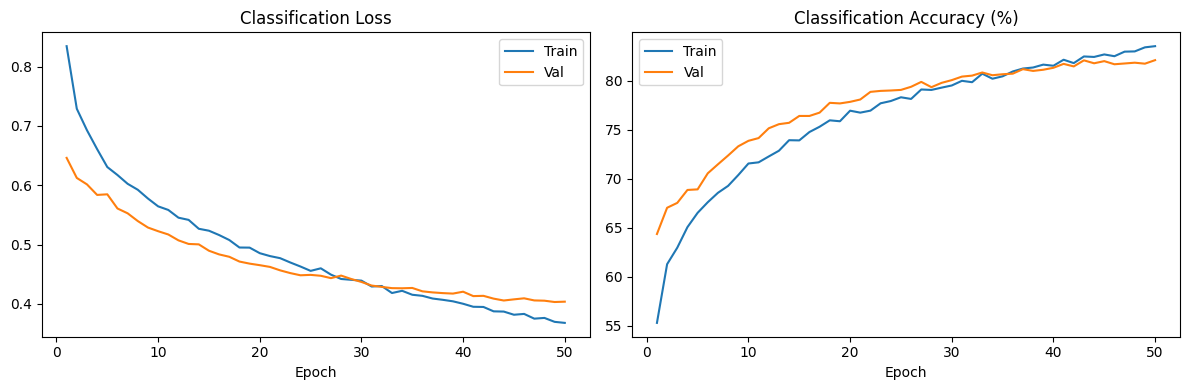

Best train accuracy: 83.55% at epoch 50
Best val accuracy: 82.12% at epoch 50


In [7]:
epochs = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_losses, label="Train")
ax1.plot(epochs, val_losses,   label="Val")
ax1.set_title("Classification Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(epochs, train_accuracies, label="Train")
ax2.plot(epochs, val_accuracies,   label="Val")
ax2.set_title("Classification Accuracy (%)")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()
print(
    f"Best train accuracy: {max(train_accuracies):.2f}% at epoch "
    f"{np.argmax(train_accuracies) + 1}"
)
print(
    f"Best val accuracy: {max(val_accuracies):.2f}% at epoch "
    f"{np.argmax(val_accuracies) + 1}"
)

### 6. Put the backbone in a YOLOv1Base model and save the entire model
We do not just save the backbone, as that makes loading it back in more difficult.

In [8]:
backbone_state_dict = model.backbone.state_dict()
# torch.save(backbone_state_dict, OUTPUT_MODEL_PATH)

temporary_model = YOLOv1Base(logger=logger)

missing, unexpected = temporary_model.backbone.load_state_dict(
    backbone_state_dict,
    strict=True
)
temporary_model.save(OUTPUT_MODEL_PATH)
print(f"Saved pretrained backbone weights to '{OUTPUT_MODEL_PATH}'")

Saved pretrained backbone weights to 'models/classification_backbone.pth'
